In [1]:
import random

import numpy as np
import matplotlib.pyplot as plot

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))

Device:  cuda
GPU:  Tesla T4


In [3]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 15

INPUT_DIM = 28 * 28
HIDDEN_DIM  = 400
LATENT_DIM = 2

In [4]:
#! Convert pixel values into range [0,1]
transform = transforms.ToTensor()


In [5]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]

Training samples: 60000
Test samples: 10000


In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 469
Test batches: 79


In [7]:
images, latent_labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", latent_labels.shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])
Minimum pixel value: 0.0
Maximum pixel value: 1.0


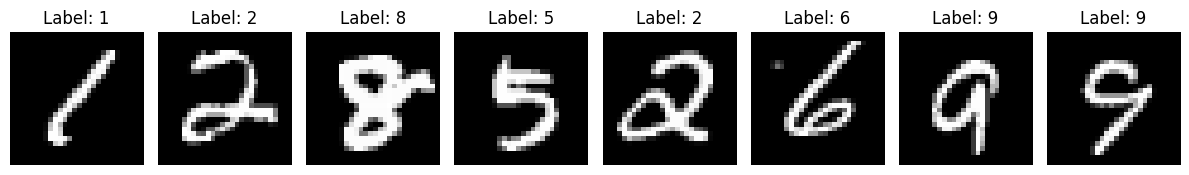

In [8]:
figure, axes = plot.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    axes[i].imshow(images[i].squeeze(),cmap="gray")
    axes[i].set_title(f"Label: {latent_labels[i].item()}")
    axes[i].axis("off")

plot.tight_layout()
plot.show()

In [9]:
class VAE(nn.Module):

    def __init__(self, input_dim = 784, hidden_dim = 400, latent_dim = 2):
        super().__init__()

        self.encoder_hidden = nn.Linear(input_dim, hidden_dim)
        self.encoder_mu = nn.Linear(hidden_dim, latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_output = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        hidden = F.relu(self.encoder_hidden(x))

        mu = self.encoder_mu(hidden)
        logvar = self.encoder_logvar(hidden)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)

        z = mu + std * epsilon
        return z

    def decode(self,z):

        hidden = F.relu(self.decoder_hidden(z))
        logits = self.decoder_output(hidden)

        return logits

    def forward(self, x):

        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)

        return logits, mu, logvar

In [10]:
model = VAE(input_dim= INPUT_DIM, hidden_dim= HIDDEN_DIM, latent_dim= LATENT_DIM).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

print(model)

VAE(
  (encoder_hidden): Linear(in_features=784, out_features=400, bias=True)
  (encoder_mu): Linear(in_features=400, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder_hidden): Linear(in_features=2, out_features=400, bias=True)
  (decoder_output): Linear(in_features=400, out_features=784, bias=True)
)


In [11]:
sample_images, _ = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    logits, mu, logvar = model(sample_images)

print("Input:", sample_images.shape)
print("Decoder output:", logits.shape)
print("Mu:", mu.shape)
print("Log variance:", logvar.shape)

Input: torch.Size([128, 1, 28, 28])
Decoder output: torch.Size([128, 784])
Mu: torch.Size([128, 2])
Log variance: torch.Size([128, 2])


In [12]:
def vae_loss(logits, x, mu, logvar):
    x = x.view(x.size(0), -1)

    reconstruction_loss = F.binary_cross_entropy_with_logits(logits, x, reduction= "sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

In [13]:
training_losses = []
reconstruction_losses = []
kl_losses = []

for epoch in range(EPOCHS):

    model.train()
    running_total_loss = 0.0
    running_reconstruction_loss = 0.0
    running_kl_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        logits, mu, logvar = model(images)

        total_loss, reconstruction_loss, kl_Loss = vae_loss(logits, images, mu, logvar)

        total_loss.backward()
        optimizer.step()

        running_total_loss += total_loss.item()
        running_reconstruction_loss += reconstruction_loss.item()
        running_kl_loss += kl_Loss.item()

    average_total_loss = (running_total_loss / len(train_dataset))
    average_reconstruction_loss = (running_reconstruction_loss / len(train_dataset))
    average_kl_loss = (running_kl_loss / len(train_dataset))

    training_losses.append(average_total_loss)
    reconstruction_losses.append(average_reconstruction_loss)
    kl_losses.append(average_kl_loss)

    print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Total Loss: {average_total_loss:.4f} | "
            f"Reconstruction: {average_reconstruction_loss:.4f} | "
            f"KL: {average_kl_loss:.4f}"
         )


Epoch [1/15] Total Loss: 190.5418 | Reconstruction: 185.0449 | KL: 5.4969
Epoch [2/15] Total Loss: 166.1578 | Reconstruction: 161.0588 | KL: 5.0990
Epoch [3/15] Total Loss: 161.7829 | Reconstruction: 156.4589 | KL: 5.3240
Epoch [4/15] Total Loss: 159.2190 | Reconstruction: 153.7463 | KL: 5.4726
Epoch [5/15] Total Loss: 157.4785 | Reconstruction: 151.8870 | KL: 5.5915
Epoch [6/15] Total Loss: 156.1695 | Reconstruction: 150.5305 | KL: 5.6390
Epoch [7/15] Total Loss: 155.1920 | Reconstruction: 149.5016 | KL: 5.6904
Epoch [8/15] Total Loss: 154.4105 | Reconstruction: 148.6731 | KL: 5.7373
Epoch [9/15] Total Loss: 153.7216 | Reconstruction: 147.9574 | KL: 5.7642
Epoch [10/15] Total Loss: 153.1105 | Reconstruction: 147.3246 | KL: 5.7859
Epoch [11/15] Total Loss: 152.6245 | Reconstruction: 146.7906 | KL: 5.8339
Epoch [12/15] Total Loss: 152.1246 | Reconstruction: 146.2620 | KL: 5.8626
Epoch [13/15] Total Loss: 151.7539 | Reconstruction: 145.8659 | KL: 5.8880
Epoch [14/15] Total Loss: 151.3907

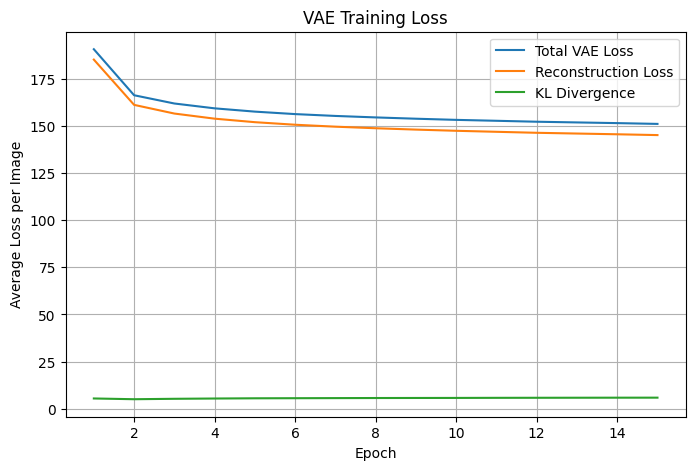

In [14]:
epochs = range(1, EPOCHS + 1)

plot.figure(figsize=(8, 5))

plot.plot(epochs, training_losses, label="Total VAE Loss")
plot.plot(epochs,reconstruction_losses, label="Reconstruction Loss")
plot.plot(epochs,kl_losses,label="KL Divergence")

plot.xlabel("Epoch")
plot.ylabel("Average Loss per Image")
plot.title("VAE Training Loss")

plot.legend()
plot.grid()

plot.show()

In [15]:
torch.save(model.state_dict(), "vae_mnist_latent2.pth")

print("Model saved.")

Model saved.


SUBTASK 2

In [17]:
model.eval()

latent_points = []
latent_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        mu,logvar = model.encode(images)

        latent_points.append(mu.cpu())
        latent_labels.append(labels)


latent_points = torch.cat(latent_points, dim = 0).numpy()
latent_labels = torch.cat(latent_labels, dim = 0).numpy()

print("Latent points shape: ", latent_points.shape)
print("Labels shape: ", latent_labels.shape)

Latent points shape:  (10000, 2)
Labels shape:  (10000,)


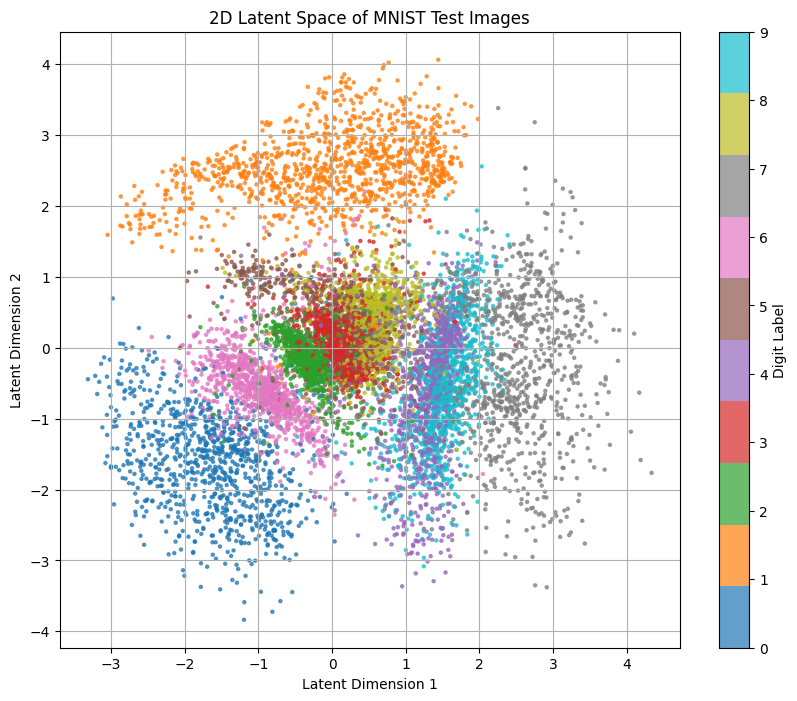

In [18]:
plot.figure(figsize=(10, 8))

scatter = plot.scatter(
                        latent_points[:, 0],
                        latent_points[:, 1],
                        c=latent_labels, cmap="tab10", s=5, alpha=0.7
                      )

plot.colorbar(scatter, ticks=range(10), label="Digit Label")
plot.xlabel("Latent Dimension 1")
plot.ylabel("Latent Dimension 2")
plot.title("2D Latent Space of MNIST Test Images")

plot.grid()
plot.show()

In [19]:
model.eval()

test_images, test_labels = next(iter(test_loader))

test_images = test_images[:10].to(device)
test_labels = test_labels[:10].to(device)

with torch.no_grad():
    mu, logvar = model.encode(test_images)

    reconstructed_logits = model.decode(mu)
    reconstructed_images = torch.sigmoid(reconstructed_logits)

    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28)

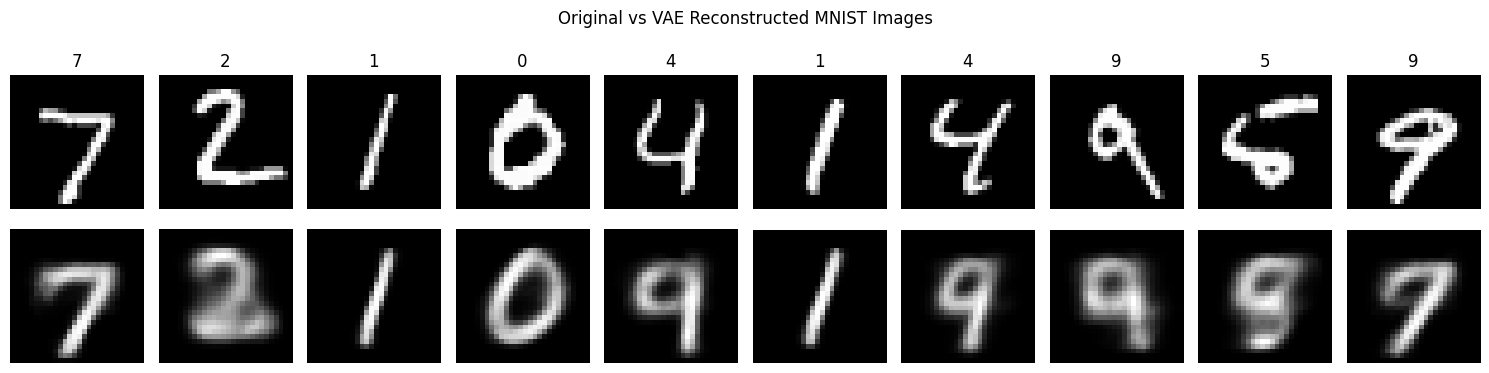

In [20]:
figure, axes = plot.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axes[0, i].imshow(test_images[i].cpu().squeeze(),cmap="gray")
    axes[0, i].set_title(f"{test_labels[i].item()}")
    axes[0, i].axis("off")


    axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")


axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plot.suptitle("Original vs VAE Reconstructed MNIST Images")

plot.tight_layout()
plot.show()

In [21]:
NUM_SAMPLES = 10

model.eval()

with torch.no_grad():

    random_z = torch.randn(NUM_SAMPLES, LATENT_DIM).to(device)

    generated_logits = model.decode(random_z)
    generated_images = torch.sigmoid(generated_logits)
    generated_images = generated_images.view(-1, 1, 28, 28)

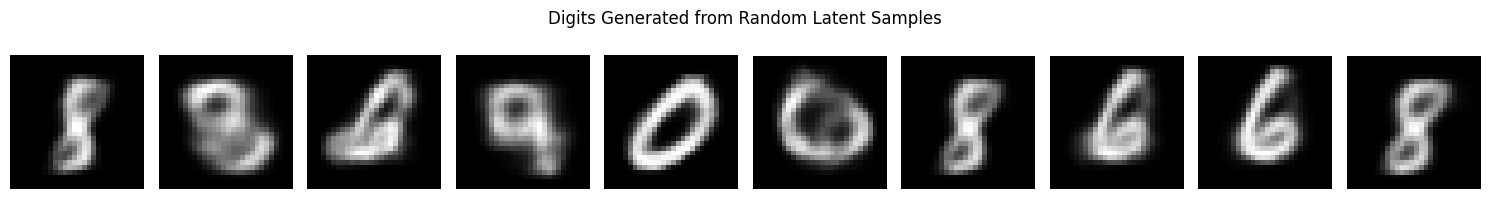

In [22]:
figure, axes = plot.subplots(1, NUM_SAMPLES, figsize=(15, 2))

for i in range(NUM_SAMPLES):
    axes[i].imshow(generated_images[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")

plot.suptitle("Digits Generated from Random Latent Samples")

plot.tight_layout()
plot.show()

## Subtask 3: Comparison with Doersch's VAE Implementation